In [24]:
from __future__ import annotations

"""
BC2410 / BC2411 Group Project
Resume-to-Job Shortlisting via Multi-Signal Scoring + MILP (v4, business-grounded)

Why this version is stronger:
- keeps binary yes/no decisions central, aligned with the discrete optimisation lectures
- fixes the infeasible must-have constraint from v2 by linking it to ACTUAL filled slots
- replaces a weak title-token category target with a stronger weighted skill-coverage service level
- prioritises scarce required skills via data-driven coverage weights
- keeps anti-redundancy cluster constraints and category concentration caps as diversification guardrails
- adds a minimum average shortlist-quality floor using a soft penalty slack
- uses a review-time safety factor to make the time-budget more robust to uncertainty
- expands sensitivity analysis to cover the new coverage-service parameter

Prompt log for notebook submission:
- Improve the MILP so the added constraints are easier to justify in business terms and with OR literature.
- Replace weak heuristics with defensible linear constraints, keep the model generic, and preserve file-based inputs/outputs.

Expected input files in current working folder:
- UpdatedResumeDataSet.csv
- job_title_des.csv

Outputs are written to outputs_resume_project_v4/
"""

# ── stdlib ────────────────────────────────────────────────────────────────────
import logging
import math
import re
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

# ── third-party ───────────────────────────────────────────────────────────────
import matplotlib
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic("matplotlib", "inline")
    else:
        matplotlib.use("Agg")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import gurobipy as gp
    from gurobipy import GRB
    HAS_GUROBI = True
except Exception:  # pragma: no cover
    HAS_GUROBI = False

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

# ── logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("resume_opt_v4")
_T0 = time.perf_counter()


def elapsed() -> str:
    return f"{time.perf_counter() - _T0:6.1f}s"



## 0) CONFIGURATION

This section defines the global settings used throughout the notebook, including file paths, random seeds, sampling limits, score weights, and optimisation parameters. Adjust these values first if you want to tune the experiment setup or control the size of the problem.

Key contents:
- Dataset and output paths, so the pipeline knows where to read inputs and save results.
- Sampling and shortlist parameters, which control problem size and business constraints.
- Scoring weights, which decide how much each similarity signal contributes to the final match score.
- Coverage, diversity, and review-time constants, which shape the optimisation model later in the notebook.

Note: this section mainly stores constants rather than defining standalone helper functions.

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# 0) CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path(".")
RESUME_FILE = BASE_DIR / "UpdatedResumeDataSet.csv"
JOB_FILE = BASE_DIR / "job_title_des.csv"
OUT_DIR = BASE_DIR / "outputs_resume_project_v4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── embeddings ────────────────────────────────────────────────────────────────
USE_SENTENCE_TRANSFORMER = False
SENTENCE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# ── sampling ──────────────────────────────────────────────────────────────────
MAX_RESUMES_PER_CATEGORY = 15
MAX_JOBS_PER_TITLE = 4
MAX_TOTAL_JOBS = 30
TOP_N_PER_JOB_PREFILTER = 30

# ── score weights ─────────────────────────────────────────────────────────────
W_TFIDF_OFF = 0.48
W_BM25_OFF = 0.12
W_SKILL_OFF = 0.26
W_CATEGORY_OFF = 0.14

W_TFIDF_ON = 0.22
W_DENSE_ON = 0.28
W_BM25_ON = 0.08
W_SKILL_ON = 0.26
W_CATEGORY_ON = 0.16

LENGTH_PENALTY_WEIGHT = 0.06
IDEAL_RESUME_WORD_COUNT = 500

# ── main operational knobs ────────────────────────────────────────────────────
SHORTLIST_SIZE_DEFAULT = 5
REVIEW_BUDGET_MINUTES_DEFAULT = 25.0
MAX_JOBS_PER_CANDIDATE = 2
MUST_HAVE_TOP_K = 6
MIN_REQUIRED_MUST_HAVE_MATCH = 1
MIN_SCORE_FLOOR = 0.35
MIN_AVG_SHORTLIST_SCORE = 0.50

BASE_REVIEW_MINUTES = 1.0
TIME_PER_100_WORDS = 1.0
REVIEW_TIME_SAFETY_MULTIPLIER = 1.15  # mild robustification for uncertain screening time

# ── bonus / penalty weights ───────────────────────────────────────────────────
COVERAGE_BONUS_WEIGHT = 0.12
UNFILLED_PENALTY = 0.35
QUALITY_SHORTFALL_PENALTY = 0.30
COVERAGE_SHORTFALL_PENALTY = 0.24

MAX_CATEGORY_SHARE = 0.60  # operational diversity, not demographic fairness
MAX_PER_REDUNDANCY_CLUSTER = 1
REDUNDANCY_SIM_THRESHOLD = 0.85
MIN_WEIGHTED_COVERAGE_RATIO = 0.55
SKILL_SCARCITY_BOOST = 1.0

# ── solve controls ────────────────────────────────────────────────────────────
TIME_LIMIT_SECONDS = 120
MIP_GAP = 0.03



## 1) SKILL VOCABULARY / TEXT HELPERS

This section prepares the text-processing foundation for the project. It stores the skill vocabulary and helper functions used to clean resume and job-description text, standardise wording, and extract signals for later scoring.

Key functions:
- `clean_text()`: lowercases text, removes noisy characters, and normalises spacing so later matching is more reliable.
- `word_count()`: counts the number of cleaned words and is used to filter weak resume entries and estimate review effort.
- `normalise_skill()`: maps different spellings or aliases of the same skill to a common standard form.
- `extract_skills()`: scans text against the skill vocabulary and returns the set of recognised skills found in a resume or job description.
- `jaccard()`: measures overlap between two skill sets and is later used as one of the matching signals.
- `safe_title_bucket()`: groups similar job titles into broader buckets so the job sampling step stays balanced.

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# 1) SKILL VOCABULARY / TEXT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

SKILL_VOCAB: list[str] = [
    # data / ML
    "machine learning", "deep learning", "natural language processing", "computer vision",
    "data analysis", "data science", "data engineering", "feature engineering",
    "reinforcement learning", "transfer learning", "time series", "forecasting",
    "a/b testing", "hypothesis testing", "causal inference",
    # languages
    "python", "r", "sql", "mysql", "postgresql", "sqlite", "mongodb", "nosql",
    "java", "c++", "c#", ".net", "php", "go", "scala", "kotlin", "swift",
    "javascript", "typescript", "html", "css",
    # ML libraries
    "pandas", "numpy", "scikit-learn", "xgboost", "lightgbm", "catboost",
    "pytorch", "tensorflow", "keras", "hugging face", "transformers",
    "matplotlib", "seaborn", "plotly",
    # BI / analytics
    "tableau", "power bi", "looker", "excel", "dbt",
    # data engineering
    "spark", "hadoop", "airflow", "kafka", "flink", "dask", "etl", "databricks",
    # cloud / infra
    "aws", "azure", "gcp", "docker", "kubernetes", "terraform", "ansible",
    "ci/cd", "jenkins", "github actions",
    # web / app
    "flask", "django", "fastapi", "streamlit", "react", "node.js",
    "rest api", "graphql", "api", "microservices",
    # engineering practices
    "git", "linux", "agile", "scrum", "jira", "devops", "testing", "selenium",
    "oop", "design patterns",
    # optimisation / OR
    "optimization", "gurobi", "cplex", "linear programming", "integer programming",
    "operations research",
    # soft skills
    "communication", "leadership", "problem solving", "project management",
    "stakeholder management",
    # extra domain terms
    "data governance", "data quality", "data warehouse", "data lake",
    "mlops", "model deployment", "model monitoring", "feature store",
    "vector database", "llm", "prompt engineering", "rag",
    "network security", "penetration testing", "cryptography",
    "blockchain", "smart contracts", "web3",
    "ios", "android", "flutter", "react native",
    "redis", "elasticsearch", "cassandra", "sap", "erp", "crm", "salesforce",
]

SKILL_SYNONYMS = {
    "nodejs": "node.js",
    "sklearn": "scikit-learn",
    "powerbi": "power bi",
    "nlp": "natural language processing",
    "ml": "machine learning",
    "ai": "machine learning",
    "ci cd": "ci/cd",
    "llms": "llm",
    "hf": "hugging face",
    "gpt": "llm",
    "bert": "transformers",
    "k8s": "kubernetes",
}

TECH_TITLE_MAP = {
    "Data Science": "Data Scientist",
    "Python Developer": "Python Developer",
    "Java Developer": "Java Developer",
    "DevOps Engineer": "DevOps Engineer",
    "Business Analyst": "Business Analyst",
    "Testing": "QA Engineer",
    "Database": "Database Developer",
    "Web Designing": "Web Developer",
    "Hadoop": "Data Engineer",
    "ETL Developer": "Data Engineer",
    "Blockchain": "Blockchain Developer",
    "PMO": "Project Manager",
    "SAP Developer": "SAP Developer",
    "Network Security Engineer": "Network Security Engineer",
    "Arts": "Creative Professional",
    "Health and fitness": "Health Professional",
}

STOPWORDS: set[str] = {
    "the", "and", "or", "a", "an", "to", "of", "for", "with", "in", "on", "at", "by",
    "is", "are", "be", "as", "that", "this", "from", "will", "have", "has", "had", "it",
    "we", "you", "your", "our", "their", "they", "can", "should", "must", "may",
    "also", "been", "was", "were", "not", "but", "if", "so", "do", "use",
}


def clean_text(text: str) -> str:
    text = str(text) if pd.notna(text) else ""
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[^a-zA-Z0-9+.#/ ]", " ", text.lower())
    return re.sub(r"\s+", " ", text).strip()


def word_count(text: str) -> int:
    return len(clean_text(text).split())


def normalise_skill(skill: str) -> str:
    return SKILL_SYNONYMS.get(skill.lower().strip(), skill.lower().strip())


def extract_skills(text: str, skill_vocab: list[str]) -> set[str]:
    txt = f" {clean_text(text)} "
    found: set[str] = set()
    for skill in sorted(skill_vocab, key=len, reverse=True):
        pattern = rf"(?<![a-z0-9]){re.escape(skill)}(?![a-z0-9])"
        if re.search(pattern, txt):
            found.add(normalise_skill(skill))
    return found


def jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / max(len(a | b), 1)


def safe_title_bucket(title: str) -> str:
    title = clean_text(title)
    for token in [
        "data scientist", "data engineer", "python developer", "java developer",
        "web developer", "software engineer", "devops engineer", "business analyst",
        "qa", "tester", "project manager", "full stack", "frontend", "backend", "analyst",
    ]:
        if token in title:
            return token
    return (title.split() or ["unknown"])[0]



## 2) BM25 / OPTIONAL DENSE EMBEDDINGS

This section defines the retrieval models used to compare resumes with job descriptions. BM25 provides a strong lexical matching baseline, while the optional dense embedding setup can be enabled when semantic similarity is needed.

Key functions and classes:
- `BM25.__init__()`: initialises the retrieval model parameters and storage for vocabulary statistics.
- `BM25.fit()`: learns document frequencies and average document length from the resume corpus.
- `BM25.score()`: scores one job description against every resume using BM25 relevance.
- `build_bm25_similarity()`: applies BM25 to every job and returns a resume-job similarity matrix.
- `build_dense_similarity()`: optionally computes semantic similarity with sentence embeddings; if embeddings are disabled or unavailable, it safely returns zeros.

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# 2) BM25 / OPTIONAL DENSE EMBEDDINGS
# ══════════════════════════════════════════════════════════════════════════════

class BM25:
    def __init__(self, k1: float = 1.5, b: float = 0.75) -> None:
        self.k1 = k1
        self.b = b
        self._vocab: dict[str, int] = {}
        self._idf = np.array([])
        self._avgdl = 0.0
        self._doc_len = np.array([])
        self._tf: list[dict[int, int]] = []

    def fit(self, documents: list[str]) -> "BM25":
        tokenised = [d.lower().split() for d in documents]
        self._avgdl = float(np.mean([len(t) for t in tokenised])) if tokenised else 1.0
        self._doc_len = np.array([len(t) for t in tokenised], dtype=np.float32)
        all_words = {w for doc in tokenised for w in doc if w not in STOPWORDS}
        self._vocab = {w: i for i, w in enumerate(sorted(all_words))}
        V, N = len(self._vocab), len(documents)
        self._tf = []
        df = np.zeros(V, dtype=np.float32)

        for doc_words in tokenised:
            tf_dict: dict[int, int] = {}
            seen: set[int] = set()
            for w in doc_words:
                if w not in self._vocab:
                    continue
                idx = self._vocab[w]
                tf_dict[idx] = tf_dict.get(idx, 0) + 1
                if idx not in seen:
                    df[idx] += 1
                    seen.add(idx)
            self._tf.append(tf_dict)

        self._idf = np.log((N - df + 0.5) / (df + 0.5) + 1).astype(np.float32)
        return self

    def score(self, query_text: str) -> np.ndarray:
        q_words = [w for w in query_text.lower().split() if w in self._vocab]
        scores = np.zeros(len(self._tf), dtype=np.float32)
        for w in q_words:
            idx = self._vocab[w]
            idf = self._idf[idx]
            for d, tf_dict in enumerate(self._tf):
                tf = tf_dict.get(idx, 0)
                dl = self._doc_len[d]
                num = tf * (self.k1 + 1)
                denom = tf + self.k1 * (1 - self.b + self.b * dl / self._avgdl)
                scores[d] += idf * num / denom
        return scores


def build_bm25_similarity(resume_df: pd.DataFrame, job_df: pd.DataFrame) -> np.ndarray:
    bm25 = BM25().fit(resume_df["resume_text_clean"].tolist())
    scores = np.zeros((len(resume_df), len(job_df)), dtype=np.float32)
    for j, jd_text in enumerate(job_df["job_text_clean"].tolist()):
        col = bm25.score(jd_text)
        if col.max() > col.min():
            col = (col - col.min()) / (col.max() - col.min())
        else:
            col = np.zeros_like(col)
        scores[:, j] = col
    return scores


def build_dense_similarity(resume_df: pd.DataFrame, job_df: pd.DataFrame) -> np.ndarray:
    if not USE_SENTENCE_TRANSFORMER:
        return np.zeros((len(resume_df), len(job_df)), dtype=np.float32)
    try:
        from sentence_transformers import SentenceTransformer
    except Exception:
        log.warning("sentence-transformers not installed; dense similarity set to zero")
        return np.zeros((len(resume_df), len(job_df)), dtype=np.float32)

    model = SentenceTransformer(SENTENCE_MODEL_NAME, device="cpu")
    kw = dict(batch_size=32, show_progress_bar=False, normalize_embeddings=True)
    r_emb = model.encode(resume_df["resume_text_clean"].tolist(), **kw)
    j_emb = model.encode(job_df["job_text_clean"].tolist(), **kw)
    return (np.array(r_emb) @ np.array(j_emb).T).astype(np.float32)



## 3) DATA LOADING / SAMPLING

This section loads the resume and job datasets, validates the required columns, removes weak or duplicated entries, and creates a balanced sample. The sampling step keeps the downstream optimisation problem manageable and more representative across categories.

Key functions:
- `load_resume_data()`: reads the resume CSV, checks the required columns, cleans the text, removes duplicates, and assigns candidate IDs.
- `load_job_data()`: reads the job CSV, validates the required fields, cleans descriptions, and assigns job IDs.
- `balanced_sample_resumes()`: caps the number of resumes taken from each resume category so one category does not dominate the analysis.
- `balanced_sample_jobs()`: groups similar job titles into buckets and samples jobs more evenly across titles.

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# 3) DATA LOADING / SAMPLING
# ══════════════════════════════════════════════════════════════════════════════

def load_resume_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    cols = {c.lower().strip(): c for c in df.columns}
    cat_col = cols.get("category")
    resume_col = cols.get("resume")
    if cat_col is None or resume_col is None:
        raise ValueError(f"Resume CSV must have Category and Resume columns. Found: {list(df.columns)}")

    out = df[[cat_col, resume_col]].copy()
    out.columns = ["resume_category", "resume_text"]
    out["resume_text"] = out["resume_text"].fillna("").astype(str)
    out["resume_category"] = out["resume_category"].fillna("Unknown").astype(str)
    out["resume_text_clean"] = out["resume_text"].map(clean_text)
    out["resume_word_count"] = out["resume_text_clean"].map(word_count)
    out = out[out["resume_word_count"] > 20].drop_duplicates("resume_text_clean").reset_index(drop=True)
    out.insert(0, "candidate_id", np.arange(1, len(out) + 1))
    log.info("[%s] Loaded %d unique resumes", elapsed(), len(out))
    return out


def load_job_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    cols = {c.lower().strip(): c for c in df.columns}
    title_col = cols.get("job title")
    desc_col = cols.get("job description")
    if title_col is None or desc_col is None:
        raise ValueError(f"Job CSV must have Job Title and Job Description columns. Found: {list(df.columns)}")

    out = df[[title_col, desc_col]].copy()
    out.columns = ["job_title", "job_description"]
    out["job_title"] = out["job_title"].fillna("Unknown").astype(str)
    out["job_description"] = out["job_description"].fillna("").astype(str)
    out["job_text_clean"] = (out["job_title"] + " " + out["job_description"]).map(clean_text)
    out = out[out["job_text_clean"].map(word_count) > 8].drop_duplicates("job_text_clean").reset_index(drop=True)
    out.insert(0, "job_id", np.arange(1, len(out) + 1))
    log.info("[%s] Loaded %d unique jobs", elapsed(), len(out))
    return out


def balanced_sample_resumes(resume_df: pd.DataFrame, max_per_category: int = MAX_RESUMES_PER_CATEGORY) -> pd.DataFrame:
    parts = []
    for _, grp in resume_df.groupby("resume_category", group_keys=False):
        n = min(len(grp), max_per_category)
        parts.append(grp.sample(n=n, random_state=RANDOM_STATE) if len(grp) > n else grp)
    out = pd.concat(parts, ignore_index=True).sort_values("candidate_id").reset_index(drop=True)
    out["candidate_id"] = np.arange(1, len(out) + 1)
    return out


def balanced_sample_jobs(job_df: pd.DataFrame, max_per_title: int = MAX_JOBS_PER_TITLE, max_total_jobs: int = MAX_TOTAL_JOBS) -> pd.DataFrame:
    tmp = job_df.copy()
    tmp["title_bucket"] = tmp["job_title"].map(safe_title_bucket)
    parts = []
    for _, grp in tmp.groupby("title_bucket", group_keys=False):
        n = min(len(grp), max_per_title)
        parts.append(grp.sample(n=n, random_state=RANDOM_STATE) if len(grp) > n else grp)
    out = pd.concat(parts, ignore_index=True)
    if len(out) > max_total_jobs:
        out = out.sample(n=max_total_jobs, random_state=RANDOM_STATE)
    out = out.sort_values("job_id").reset_index(drop=True)
    out["job_id"] = np.arange(1, len(out) + 1)
    return out



## 4) FEATURE ENGINEERING

This section converts raw text into structured matching features. It extracts skill sets, computes similarity scores, estimates required skills, and builds the candidate-job pair data that feeds the optimisation model.

Key functions and classes:
- `add_skill_sets()`: adds extracted skill sets and skill counts to both the resume and job tables.
- `infer_job_required_skills()`: selects the most important skills from a job description to represent must-have requirements.
- `build_tfidf_similarity()`: creates a TF-IDF cosine-similarity matrix between resumes and jobs.
- `category_alignment_score()`: gives a simple similarity score between a resume category and a job title.
- `review_minutes()`: estimates how long it would take a recruiter to review a resume based on its length.
- `_weights()`: returns the scoring weights used when dense embeddings are on or off.
- `UnionFind.find()` and `UnionFind.union()`: support grouping highly similar resumes into redundancy clusters.
- `build_redundancy_clusters()`: detects near-duplicate resumes so shortlist diversity can be enforced.
- `build_pair_table()`: combines all matching signals into one candidate-job table and computes the composite score for each pair.
- `build_skill_weight_map()`: gives higher weight to scarce required skills so coverage focuses on harder-to-find capabilities.
- `prefilter_top_candidates()`: trims the pair table to the top candidates per job before optimisation to reduce model size.

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# 4) FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════

def add_skill_sets(resume_df: pd.DataFrame, job_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    resume_df = resume_df.copy()
    job_df = job_df.copy()
    resume_df["skill_set"] = resume_df["resume_text_clean"].map(lambda t: extract_skills(t, SKILL_VOCAB))
    job_df["skill_set"] = job_df["job_text_clean"].map(lambda t: extract_skills(t, SKILL_VOCAB))
    resume_df["num_skills"] = resume_df["skill_set"].map(len)
    job_df["num_skills"] = job_df["skill_set"].map(len)
    return resume_df, job_df


def infer_job_required_skills(job_skill_set: set[str], jd_text: str, top_k: int = MUST_HAVE_TOP_K) -> list[str]:
    return sorted(job_skill_set, key=lambda s: (-len(s), s))[:top_k]


def build_tfidf_similarity(resume_df: pd.DataFrame, job_df: pd.DataFrame) -> np.ndarray:
    corpus = pd.concat([resume_df["resume_text_clean"], job_df["job_text_clean"]], ignore_index=True)
    vectorizer = TfidfVectorizer(stop_words=list(STOPWORDS), ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
    X = vectorizer.fit_transform(corpus)
    X_r = X[: len(resume_df)]
    X_j = X[len(resume_df):]
    return cosine_similarity(X_r, X_j)


def category_alignment_score(resume_category: str, job_title: str) -> float:
    mapped = TECH_TITLE_MAP.get(resume_category, resume_category)
    a = set(clean_text(mapped).split())
    b = set(clean_text(job_title).split())
    return len(a & b) / len(a | b) if a and b else 0.0


def review_minutes(n_words: int) -> float:
    base = BASE_REVIEW_MINUTES + TIME_PER_100_WORDS * (n_words / 100.0)
    return REVIEW_TIME_SAFETY_MULTIPLIER * base


def _weights(dense_on: bool) -> dict[str, float]:
    if dense_on:
        return {
            "tfidf": W_TFIDF_ON,
            "dense": W_DENSE_ON,
            "bm25": W_BM25_ON,
            "skill": W_SKILL_ON,
            "category": W_CATEGORY_ON,
        }
    return {
        "tfidf": W_TFIDF_OFF,
        "dense": 0.0,
        "bm25": W_BM25_OFF,
        "skill": W_SKILL_OFF,
        "category": W_CATEGORY_OFF,
    }


class UnionFind:
    def __init__(self, items: Iterable[int]) -> None:
        self.parent = {i: i for i in items}

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra


def build_redundancy_clusters(resume_df: pd.DataFrame, threshold: float = REDUNDANCY_SIM_THRESHOLD) -> pd.DataFrame:
    """Cluster near-duplicate resumes so each shortlist avoids multiple clones."""
    if len(resume_df) == 0:
        resume_df = resume_df.copy()
        resume_df["redundancy_cluster"] = []
        return resume_df

    vec = TfidfVectorizer(stop_words=list(STOPWORDS), ngram_range=(1, 2), min_df=1, max_df=0.95, sublinear_tf=True)
    X = vec.fit_transform(resume_df["resume_text_clean"])
    sim = cosine_similarity(X)
    uf = UnionFind(resume_df["candidate_id"].tolist())
    ids = resume_df["candidate_id"].tolist()
    cats = resume_df["resume_category"].tolist()
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            # only cluster within same broad category to avoid over-merging dissimilar people
            if cats[a] != cats[b]:
                continue
            if sim[a, b] >= threshold:
                uf.union(ids[a], ids[b])
    cluster_map = {cid: uf.find(cid) for cid in ids}
    out = resume_df.copy()
    out["redundancy_cluster"] = out["candidate_id"].map(cluster_map)
    return out


def build_pair_table(resume_df: pd.DataFrame, job_df: pd.DataFrame) -> pd.DataFrame:
    log.info("[%s] Computing TF-IDF similarity …", elapsed())
    tfidf_sim = build_tfidf_similarity(resume_df, job_df)
    log.info("[%s] Computing BM25 similarity …", elapsed())
    bm25_sim = build_bm25_similarity(resume_df, job_df)
    log.info("[%s] Computing dense similarity …", elapsed())
    dense_sim = build_dense_similarity(resume_df, job_df)
    W = _weights(USE_SENTENCE_TRANSFORMER)

    rows: list[dict] = []
    for i, r in resume_df.iterrows():
        rskills = r["skill_set"]
        review_min = review_minutes(int(r["resume_word_count"]))
        for j, job in job_df.iterrows():
            jskills = job["skill_set"]
            must_have = job["required_skills"]
            must_have_hits = sum(skill in rskills for skill in must_have)
            eligible = int(must_have_hits >= min(MIN_REQUIRED_MUST_HAVE_MATCH, len(must_have)) if must_have else 1)
            skill_overlap = jaccard(rskills, jskills)
            cat_align = category_alignment_score(r["resume_category"], job["job_title"])
            length_penalty = abs(int(r["resume_word_count"]) - IDEAL_RESUME_WORD_COUNT) / IDEAL_RESUME_WORD_COUNT
            base = (
                W["tfidf"] * float(tfidf_sim[i, j])
                + W["bm25"] * float(bm25_sim[i, j])
                + W["dense"] * float(dense_sim[i, j])
                + W["skill"] * skill_overlap
                + W["category"] * cat_align
                - LENGTH_PENALTY_WEIGHT * length_penalty
            )
            rows.append({
                "candidate_id": int(r["candidate_id"]),
                "job_id": int(job["job_id"]),
                "resume_category": r["resume_category"],
                "job_title": job["job_title"],
                "tfidf_sim": float(tfidf_sim[i, j]),
                "bm25_sim": float(bm25_sim[i, j]),
                "dense_sim": float(dense_sim[i, j]),
                "skill_overlap": float(skill_overlap),
                "category_align": float(cat_align),
                "length_penalty": float(length_penalty),
                "base_score": float(base),
                "review_minutes": float(review_min),
                "eligible": int(eligible),
                "must_have_hits": int(must_have_hits),
                "candidate_skill_set": set(rskills),
                "job_skill_set": set(jskills),
                "redundancy_cluster": int(r["redundancy_cluster"]),
            })

    pair_df = pd.DataFrame(rows)
    scaler = MinMaxScaler()
    pair_df["score"] = scaler.fit_transform(pair_df[["base_score"]])
    log.info("[%s] Pair table built: %d rows, %d eligible", elapsed(), len(pair_df), int(pair_df["eligible"].sum()))
    return pair_df


def build_skill_weight_map(pair_df: pd.DataFrame, job_df: pd.DataFrame) -> dict[tuple[int, str], float]:
    """
    Weight required skills by scarcity in the sampled candidate pool.
    We normalise weights within each job so the mean required-skill weight is 1.
    """
    if pair_df.empty:
        return {}

    candidate_rows = pair_df[["candidate_id", "candidate_skill_set"]].drop_duplicates("candidate_id")
    candidate_skills = {
        int(row.candidate_id): set(row.candidate_skill_set)
        for row in candidate_rows.itertuples(index=False)
    }
    total_candidates = max(len(candidate_skills), 1)

    skill_counts: Counter[str] = Counter()
    for sset in candidate_skills.values():
        skill_counts.update(set(sset))

    skill_weight_map: dict[tuple[int, str], float] = {}
    for row in job_df[["job_id", "required_skills"]].itertuples(index=False):
        job_id = int(row.job_id)
        required = list(row.required_skills)
        if not required:
            continue

        raw_weights: dict[str, float] = {}
        for skill in required:
            prevalence = skill_counts.get(skill, 0) / total_candidates
            raw_weights[skill] = 1.0 + SKILL_SCARCITY_BOOST * (1.0 - prevalence)

        mean_weight = float(np.mean(list(raw_weights.values()))) if raw_weights else 1.0
        for skill, raw_weight in raw_weights.items():
            skill_weight_map[(job_id, skill)] = float(raw_weight / max(mean_weight, 1e-9))

    return skill_weight_map


def prefilter_top_candidates(pair_df: pd.DataFrame, top_n_per_job: int = TOP_N_PER_JOB_PREFILTER) -> pd.DataFrame:
    filtered = (
        pair_df[pair_df["eligible"] == 1]
        .sort_values(["job_id", "score"], ascending=[True, False])
        .groupby("job_id", group_keys=False)
        .head(top_n_per_job)
        .reset_index(drop=True)
    )
    log.info("[%s] After pre-filter: %d pairs", elapsed(), len(filtered))
    return filtered



## 5) OPTIMISATION

This section formulates and solves the main shortlist optimisation model. It combines score maximisation with business rules such as shortlist size, review-time limits, candidate exposure, coverage requirements, and diversity controls.

Key functions and classes:
- `SolveResult`: stores the optimisation output, including selected pairs, summaries, solver status, and solve time.
- `summarise_shortlists()`: creates a per-job summary of shortlist size, average score, and time usage.
- `summarise_coverage()`: measures how well each shortlist covers the required skills for its job.
- `ndcg_at_k()`: evaluates ranking quality by comparing selected candidates with the highest-scoring available candidates.
- `simpson_diversity()`: measures how diverse the selected shortlist is across resume categories.
- `redundancy_ratio()`: checks whether the shortlist avoids selecting too many near-duplicate resumes.
- `coverage_per_minute()`: tracks how efficiently review time is converted into skill coverage.
- `evaluate_solution()`: packages the main evaluation metrics for one method into a comparable summary row.
- `solve_resume_shortlisting()`: builds and solves the MILP model that chooses the final shortlist under all constraints.

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# 5) OPTIMISATION
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class SolveResult:
    selected_pairs: pd.DataFrame
    objective_value: Optional[float]
    solver_status: str
    shortlist_summary: pd.DataFrame
    coverage_summary: pd.DataFrame
    solve_time_s: float = 0.0


def summarise_shortlists(selected_df: pd.DataFrame, pair_df: pd.DataFrame, job_df: pd.DataFrame, shortlist_size: int, review_budget_minutes: float) -> pd.DataFrame:
    rows = []
    for row in job_df.itertuples(index=False):
        j = int(row.job_id)
        sel = selected_df[selected_df["job_id"] == j] if (not selected_df.empty and "job_id" in selected_df.columns) else pd.DataFrame()
        rows.append({
            "job_id": j,
            "job_title": row.job_title,
            "selected_count": int(len(sel)),
            "target_shortlist_size": int(shortlist_size),
            "avg_score": float(sel["score"].mean()) if len(sel) else 0.0,
            "total_review_minutes": float(sel["review_minutes"].sum()) if len(sel) else 0.0,
            "review_budget_minutes": float(review_budget_minutes),
            "avg_must_have_hits": float(sel["must_have_hits"].mean()) if len(sel) else 0.0,
            "distinct_categories_selected": int(sel["resume_category"].nunique()) if len(sel) else 0,
            "selected_categories": ", ".join(sorted(sel["resume_category"].astype(str).unique())) if len(sel) else "",
            "selected_clusters": int(sel["redundancy_cluster"].nunique()) if len(sel) else 0,
        })
    return pd.DataFrame(rows)


def summarise_coverage(selected_df: pd.DataFrame, job_df: pd.DataFrame, pair_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    skill_weight_map = build_skill_weight_map(pair_df, job_df) if pair_df is not None else {}
    rows = []
    for row in job_df.itertuples(index=False):
        j = int(row.job_id)
        req = set(row.required_skills)
        sel = selected_df[selected_df["job_id"] == j] if (not selected_df.empty and "job_id" in selected_df.columns) else pd.DataFrame()
        covered = set()
        if len(sel):
            for sset in sel["candidate_skill_set"]:
                covered |= set(sset)
        covered_weight = float(sum(skill_weight_map.get((j, s), 1.0) for s in req if s in covered))
        total_weight = float(sum(skill_weight_map.get((j, s), 1.0) for s in req))
        rows.append({
            "job_id": j,
            "job_title": row.job_title,
            "num_required_skills": int(len(req)),
            "covered_required_skills": int(len(req & covered)),
            "coverage_rate": float(len(req & covered) / max(len(req), 1)),
            "covered_required_skill_weight": covered_weight,
            "total_required_skill_weight": total_weight,
            "weighted_coverage_rate": float(covered_weight / max(total_weight, 1.0)),
            "required_skills": ", ".join(sorted(req)),
        })
    return pd.DataFrame(rows)


def ndcg_at_k(selected_df: pd.DataFrame, pair_df: pd.DataFrame, k: int) -> float:
    if selected_df.empty or "job_id" not in selected_df.columns:
        return 0.0
    vals: list[float] = []
    for job_id, sel in selected_df.groupby("job_id"):
        actual = sel.sort_values("score", ascending=False)["score"].head(k).tolist()
        pool = pair_df[(pair_df["job_id"] == job_id) & (pair_df["eligible"] == 1)]
        ideal = pool.nlargest(k, "score")["score"].tolist()
        if not ideal:
            continue
        dcg = sum(s / math.log2(i + 2) for i, s in enumerate(actual))
        idcg = sum(s / math.log2(i + 2) for i, s in enumerate(ideal))
        vals.append(dcg / idcg if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0


def simpson_diversity(selected_df: pd.DataFrame) -> float:
    if len(selected_df) < 2:
        return 0.0
    counts = selected_df["resume_category"].value_counts().values
    N = counts.sum()
    if N < 2:
        return 0.0
    return 1.0 - sum(n * (n - 1) for n in counts) / (N * (N - 1))


def redundancy_ratio(selected_df: pd.DataFrame) -> float:
    if len(selected_df) == 0 or "redundancy_cluster" not in selected_df.columns:
        return 0.0
    return float(selected_df["redundancy_cluster"].nunique() / max(len(selected_df), 1))


def coverage_per_minute(selected_df: pd.DataFrame, job_df: pd.DataFrame) -> float:
    cov_df = summarise_coverage(selected_df, job_df)
    vals: list[float] = []
    for row in cov_df.itertuples(index=False):
        sel = selected_df[selected_df["job_id"] == row.job_id] if "job_id" in selected_df.columns else pd.DataFrame()
        total_min = float(sel["review_minutes"].sum()) if len(sel) else 0.0
        if total_min > 0:
            vals.append(row.covered_required_skills / total_min)
    return float(np.mean(vals)) if vals else 0.0


def evaluate_solution(selected_df: pd.DataFrame, pair_df: pd.DataFrame, job_df: pd.DataFrame, name: str, shortlist_size: int, review_budget_minutes: float) -> pd.Series:
    shortlist_sum = summarise_shortlists(selected_df, pair_df, job_df, shortlist_size, review_budget_minutes)
    coverage_sum = summarise_coverage(selected_df, job_df, pair_df)
    return pd.Series({
        "method": name,
        "total_pairs_selected": int(len(selected_df)),
        "mean_selected_score": float(selected_df["score"].mean()) if len(selected_df) else 0.0,
        "mean_review_minutes_per_job": float(shortlist_sum["total_review_minutes"].mean()) if len(shortlist_sum) else 0.0,
        "mean_selected_per_job": float(shortlist_sum["selected_count"].mean()) if len(shortlist_sum) else 0.0,
        "mean_coverage_rate": float(coverage_sum["coverage_rate"].mean()) if len(coverage_sum) else 0.0,
        "mean_weighted_coverage_rate": float(coverage_sum["weighted_coverage_rate"].mean()) if len(coverage_sum) else 0.0,
        "ndcg_at_k": ndcg_at_k(selected_df, pair_df, shortlist_size),
        "simpson_diversity": simpson_diversity(selected_df),
        "redundancy_uniqueness": redundancy_ratio(selected_df),
        "coverage_per_review_min": coverage_per_minute(selected_df, job_df),
        "jobs_underfilled": int((shortlist_sum["selected_count"] < shortlist_size).sum()) if len(shortlist_sum) else 0,
        "eligible_pairs": int(pair_df["eligible"].sum()),
    })


def solve_resume_shortlisting(
    pair_df: pd.DataFrame,
    job_df: pd.DataFrame,
    shortlist_size: int = SHORTLIST_SIZE_DEFAULT,
    review_budget_minutes: float = REVIEW_BUDGET_MINUTES_DEFAULT,
    max_jobs_per_candidate: int = MAX_JOBS_PER_CANDIDATE,
    coverage_bonus_weight: float = COVERAGE_BONUS_WEIGHT,
    unfilled_penalty: float = UNFILLED_PENALTY,
    min_score_floor: float = MIN_SCORE_FLOOR,
    min_avg_score: float = MIN_AVG_SHORTLIST_SCORE,
    min_weighted_coverage_ratio: float = MIN_WEIGHTED_COVERAGE_RATIO,
    time_limit: int = TIME_LIMIT_SECONDS,
    mip_gap: float = MIP_GAP,
    warm_start_df: Optional[pd.DataFrame] = None,
) -> SolveResult:
    start = time.perf_counter()
    if pair_df.empty:
        empty = pair_df.head(0).copy()
        return SolveResult(empty, None, "empty_pair_df", pd.DataFrame(), pd.DataFrame(), 0.0)
    if not HAS_GUROBI:
        raise RuntimeError("gurobipy is required for this v3 script")

    # hard quality floor inside the model pool
    pair_df = pair_df[pair_df["score"] >= min_score_floor].copy().reset_index(drop=True)
    if pair_df.empty:
        empty = pair_df.head(0).copy()
        return SolveResult(empty, None, "no_pairs_above_floor", pd.DataFrame(), pd.DataFrame(), 0.0)

    jobs = sorted(job_df["job_id"].tolist())
    candidates = sorted(pair_df["candidate_id"].unique().tolist())
    pair_keys = [(int(r.candidate_id), int(r.job_id)) for r in pair_df.itertuples(index=False)]

    score_map = {(int(r.candidate_id), int(r.job_id)): float(r.score) for r in pair_df.itertuples(index=False)}
    review_map = {(int(r.candidate_id), int(r.job_id)): float(r.review_minutes) for r in pair_df.itertuples(index=False)}
    mhits_map = {(int(r.candidate_id), int(r.job_id)): int(r.must_have_hits) for r in pair_df.itertuples(index=False)}
    cat_map = {int(r.candidate_id): r.resume_category for r in pair_df[["candidate_id", "resume_category"]].drop_duplicates().itertuples(index=False)}
    cluster_map = {int(r.candidate_id): int(r.redundancy_cluster) for r in pair_df[["candidate_id", "redundancy_cluster"]].drop_duplicates().itertuples(index=False)}
    cand_skill_map = {int(r.candidate_id): set(r.candidate_skill_set) for r in pair_df[["candidate_id", "candidate_skill_set"]].drop_duplicates("candidate_id").itertuples(index=False)}
    job_req_skills = {int(r.job_id): list(r.required_skills) for r in job_df[["job_id", "required_skills"]].itertuples(index=False)}
    skill_weight_map = build_skill_weight_map(pair_df, job_df)

    pairs_by_job: dict[int, list[tuple[int, int]]] = defaultdict(list)
    jobs_by_candidate: dict[int, list[int]] = defaultdict(list)
    for i, j in pair_keys:
        pairs_by_job[j].append((i, j))
        jobs_by_candidate[i].append(j)

    warm_set: set[tuple[int, int]] = set()
    if warm_start_df is not None and len(warm_start_df):
        warm_set = {(int(r.candidate_id), int(r.job_id)) for r in warm_start_df.itertuples(index=False)}

    m = gp.Model("resume_shortlisting_v4")
    m.setParam("OutputFlag", 0)
    m.setParam("TimeLimit", time_limit)
    m.setParam("MIPGap", mip_gap)
    m.setParam("Presolve", 2)
    m.setParam("Threads", 0)
    m.setParam("Heuristics", 0.2)

    x = m.addVars(pair_keys, vtype=GRB.BINARY, name="x")
    u = m.addVars(jobs, lb=0.0, vtype=GRB.CONTINUOUS, name="unfilled")
    qual_slack = m.addVars(jobs, lb=0.0, vtype=GRB.CONTINUOUS, name="qual_slack")
    cov_slack = m.addVars(jobs, lb=0.0, vtype=GRB.CONTINUOUS, name="cov_slack")
    skill_keys = [(j, s) for j in jobs for s in job_req_skills.get(j, [])]
    y = m.addVars(skill_keys, vtype=GRB.BINARY, name="skillcov")

    if warm_set:
        for i, j in pair_keys:
            x[i, j].Start = 1.0 if (i, j) in warm_set else 0.0

    # C1 shortlist size (soft)
    for j in jobs:
        jp = pairs_by_job.get(j, [])
        m.addConstr(gp.quicksum(x[i, j] for i, j in jp) + u[j] == shortlist_size, name=f"shortlist_{j}")

    # C2 recruiter review budget (robustified by REVIEW_TIME_SAFETY_MULTIPLIER inside review_map)
    for j in jobs:
        jp = pairs_by_job.get(j, [])
        m.addConstr(gp.quicksum(review_map[i, j] * x[i, j] for i, j in jp) <= review_budget_minutes, name=f"budget_{j}")

    # C3 candidate exposure cap
    for i in candidates:
        cj = jobs_by_candidate.get(i, [])
        if cj:
            m.addConstr(gp.quicksum(x[i, j] for j in cj) <= max_jobs_per_candidate, name=f"cap_{i}")

    # C4 skill coverage linking
    for j in jobs:
        req = job_req_skills.get(j, [])
        job_candidates = [i for i, _ in pairs_by_job.get(j, [])]
        for s in req:
            safe_s = re.sub(r"\W", "_", s)
            covers = [i for i in job_candidates if s in cand_skill_map.get(i, set())]
            if covers:
                m.addConstr(y[j, s] <= gp.quicksum(x[i, j] for i in covers), name=f"cov_ub_{j}_{safe_s}")
                for i in covers:
                    m.addConstr(y[j, s] >= x[i, j], name=f"cov_lb_{j}_{safe_s}_{i}")
            else:
                m.addConstr(y[j, s] == 0, name=f"cov_none_{j}_{safe_s}")

    # C5 must-have hits linked to actual number filled (fixes infeasibility from previous version)
    for j in jobs:
        jp = pairs_by_job.get(j, [])
        req = job_req_skills.get(j, [])
        if req and jp:
            m.addConstr(
                gp.quicksum(mhits_map[i, j] * x[i, j] for i, j in jp) >= MIN_REQUIRED_MUST_HAVE_MATCH * (shortlist_size - u[j]),
                name=f"mhits_{j}",
            )

    # C6 soft average shortlist-quality floor
    for j in jobs:
        jp = pairs_by_job.get(j, [])
        if jp:
            m.addConstr(
                gp.quicksum(score_map[i, j] * x[i, j] for i, j in jp) + qual_slack[j] >= min_avg_score * (shortlist_size - u[j]),
                name=f"avg_quality_{j}",
            )

    # C7 soft weighted skill-coverage floor
    for j in jobs:
        req = job_req_skills.get(j, [])
        if not req:
            continue
        total_req_weight = sum(skill_weight_map[j, s] for s in req)
        m.addConstr(
            gp.quicksum(skill_weight_map[j, s] * y[j, s] for s in req) + cov_slack[j]
            >= min_weighted_coverage_ratio * total_req_weight * (shortlist_size - u[j]) / max(shortlist_size, 1),
            name=f"cov_floor_{j}",
        )

    # C8 category concentration cap
    cap_count = max(1, math.ceil(MAX_CATEGORY_SHARE * shortlist_size))
    for j in jobs:
        jp = pairs_by_job.get(j, [])
        # hard concentration cap: no one category should dominate the shortlist
        categories = sorted({cat_map.get(i) for i, _ in jp})
        for c in categories:
            cand_ids = [i for i, _ in jp if cat_map.get(i) == c]
            if cand_ids:
                m.addConstr(gp.quicksum(x[i, j] for i in cand_ids) <= cap_count, name=f"cat_cap_{j}_{re.sub(r'\W','_', c)}")

    # C9 anti-redundancy common relation: at most one near-duplicate candidate from same cluster per job
    for j in jobs:
        job_candidates = [i for i, _ in pairs_by_job.get(j, [])]
        clusters_in_job = defaultdict(list)
        for i in job_candidates:
            clusters_in_job[cluster_map[i]].append(i)
        for cl, cand_ids in clusters_in_job.items():
            if len(cand_ids) > 1:
                m.addConstr(gp.quicksum(x[i, j] for i in cand_ids) <= MAX_PER_REDUNDANCY_CLUSTER, name=f"cluster_cap_{j}_{cl}")

    # Objective
    quality = gp.quicksum(score_map[i, j] * x[i, j] for i, j in pair_keys)
    coverage = coverage_bonus_weight * gp.quicksum(skill_weight_map[j, s] * y[j, s] for j, s in skill_keys)
    unfilled = unfilled_penalty * gp.quicksum(u[j] for j in jobs)
    qual_pen = QUALITY_SHORTFALL_PENALTY * gp.quicksum(qual_slack[j] for j in jobs)
    cov_pen = COVERAGE_SHORTFALL_PENALTY * gp.quicksum(cov_slack[j] for j in jobs)
    m.setObjective(quality + coverage - unfilled - qual_pen - cov_pen, GRB.MAXIMIZE)
    m.optimize()

    solve_time = time.perf_counter() - start

    if m.SolCount == 0:
        empty = pair_df.head(0).copy()
        shortlist_sum = summarise_shortlists(empty, pair_df, job_df, shortlist_size, review_budget_minutes)
        coverage_sum = summarise_coverage(empty, job_df, pair_df)
        return SolveResult(empty, None, f"gurobi_no_sol_{m.Status}", shortlist_sum, coverage_sum, solve_time)

    status_name = {
        GRB.OPTIMAL: "optimal",
        GRB.TIME_LIMIT: "time_limit_feasible",
        GRB.SUBOPTIMAL: "suboptimal_feasible",
    }.get(m.Status, f"gurobi_status_{m.Status}")

    selected_rows = [
        pair_df[(pair_df["candidate_id"] == i) & (pair_df["job_id"] == j)].iloc[0].to_dict()
        for i, j in pair_keys if x[i, j].X > 0.5
    ]
    selected_df = pd.DataFrame(selected_rows)
    shortlist_sum = summarise_shortlists(selected_df, pair_df, job_df, shortlist_size, review_budget_minutes)
    coverage_sum = summarise_coverage(selected_df, job_df, pair_df)
    log.info("[%s] MILP done: status=%s ObjVal=%.4f SolveTime=%.2fs", elapsed(), status_name, float(m.ObjVal), solve_time)
    return SolveResult(selected_df, float(m.ObjVal), status_name, shortlist_sum, coverage_sum, solve_time)



## 6) BASELINES

This section implements simpler benchmark methods for comparison with the optimisation approach. These baselines help show whether the MILP model delivers better shortlist quality, coverage, and constraint handling than straightforward greedy selection.

Key functions:
- `greedy_baseline()`: fills each shortlist step by step using the best available candidates while still respecting major business constraints.
- `score_only_baseline()`: selects the highest-scoring candidates for each job without enforcing the richer optimisation logic, giving a simple benchmark.

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# 6) BASELINES
# ══════════════════════════════════════════════════════════════════════════════

def greedy_baseline(pair_df: pd.DataFrame, shortlist_size: int = SHORTLIST_SIZE_DEFAULT, review_budget_minutes: float = REVIEW_BUDGET_MINUTES_DEFAULT, max_jobs_per_candidate: int = MAX_JOBS_PER_CANDIDATE, min_score_floor: float = MIN_SCORE_FLOOR) -> pd.DataFrame:
    chosen: list[dict] = []
    exposure: Counter[int] = Counter()
    job_cluster_used: dict[int, set[int]] = defaultdict(set)
    job_cat_counts: dict[int, Counter[str]] = defaultdict(Counter)
    cap_count = max(1, math.ceil(MAX_CATEGORY_SHARE * shortlist_size))

    eligible = pair_df[(pair_df["eligible"] == 1) & (pair_df["score"] >= min_score_floor)]
    for job_id, grp in eligible.sort_values(["job_id", "score"], ascending=[True, False]).groupby("job_id"):
        used_time = 0.0
        used = 0
        for row in grp.itertuples(index=False):
            if used >= shortlist_size:
                break
            if exposure[row.candidate_id] >= max_jobs_per_candidate:
                continue
            if used_time + row.review_minutes > review_budget_minutes:
                continue
            if row.redundancy_cluster in job_cluster_used[job_id]:
                continue
            if job_cat_counts[job_id][row.resume_category] >= cap_count:
                continue
            chosen.append(row._asdict())
            exposure[row.candidate_id] += 1
            used += 1
            used_time += row.review_minutes
            job_cluster_used[job_id].add(row.redundancy_cluster)
            job_cat_counts[job_id][row.resume_category] += 1
    return pd.DataFrame(chosen)


def score_only_baseline(pair_df: pd.DataFrame, shortlist_size: int = SHORTLIST_SIZE_DEFAULT, min_score_floor: float = MIN_SCORE_FLOOR) -> pd.DataFrame:
    eligible = pair_df[(pair_df["eligible"] == 1) & (pair_df["score"] >= min_score_floor)]
    chunks = [grp.nlargest(shortlist_size, "score") for _, grp in eligible.groupby("job_id")]
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()



## 7) SENSITIVITY ANALYSIS

This section tests how sensitive the final recommendations are to key modelling choices. By varying shortlist size, time budget, coverage weight, score floor, and service-level settings, it checks whether the conclusions remain stable under different assumptions.

Key function:
- `run_sensitivity()`: reruns the optimisation across multiple parameter combinations and records how the solution quality changes under different assumptions.

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# 7) SENSITIVITY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def run_sensitivity(pair_df: pd.DataFrame, job_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    configs = [
        (k, b, cbw, sf, cov_floor)
        for k in [5, 10]
        for b in [25, 35]
        for cbw in [0.08, 0.12, 0.18]
        for sf in [0.30, 0.35, 0.40]
        for cov_floor in [0.45, 0.55]
    ]
    log.info("[%s] Running sensitivity over %d configurations …", elapsed(), len(configs))
    for k, b, cbw, sf, cov_floor in configs:
        res = solve_resume_shortlisting(
            pair_df=pair_df,
            job_df=job_df,
            shortlist_size=k,
            review_budget_minutes=b,
            coverage_bonus_weight=cbw,
            min_score_floor=sf,
            min_weighted_coverage_ratio=cov_floor,
            time_limit=60,
            mip_gap=0.05,
        )
        rows.append({
            "shortlist_size": k,
            "review_budget_minutes": b,
            "coverage_bonus_weight": cbw,
            "min_score_floor": sf,
            "min_weighted_coverage_ratio": cov_floor,
            "solver_status": res.solver_status,
            "objective_value": res.objective_value,
            "mean_selected_count": float(res.shortlist_summary["selected_count"].mean()) if len(res.shortlist_summary) else 0.0,
            "mean_avg_score": float(res.shortlist_summary["avg_score"].mean()) if len(res.shortlist_summary) else 0.0,
            "mean_coverage_rate": float(res.coverage_summary["coverage_rate"].mean()) if len(res.coverage_summary) else 0.0,
            "mean_weighted_coverage_rate": float(res.coverage_summary["weighted_coverage_rate"].mean()) if len(res.coverage_summary) else 0.0,
            "jobs_underfilled": int((res.shortlist_summary["selected_count"] < k).sum()) if len(res.shortlist_summary) else len(job_df),
            "solve_time_s": res.solve_time_s,
        })
    return pd.DataFrame(rows)



## 8) CHARTS

This section generates visual summaries of the results. The charts are used to compare methods, inspect score distributions, and communicate the trade-offs found by the optimisation and sensitivity analysis.

Key functions:
- `_save()`: saves each chart to the output folder with consistent export settings.
- `plot_score_distribution()`: shows the distribution of composite match scores among eligible resume-job pairs.
- `plot_method_comparison()`: creates side-by-side comparisons of the optimisation model and baseline methods across evaluation metrics.

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# 8) CHARTS
# ══════════════════════════════════════════════════════════════════════════════

def _save(fig: plt.Figure, name: str) -> None:
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    log.info("[%s] Chart saved: %s", elapsed(), path.name)


def plot_score_distribution(pair_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    scores = pair_df[pair_df["eligible"] == 1]["score"]
    ax.hist(scores, bins=30, edgecolor="white", alpha=0.9)
    ax.set_xlabel("Composite score")
    ax.set_ylabel("Frequency")
    ax.set_title("Composite score distribution")
    _save(fig, "score_distribution")


def plot_method_comparison(comp: pd.DataFrame) -> None:
    metrics = [
        ("mean_selected_score", "Mean score"),
        ("mean_coverage_rate", "Coverage rate"),
        ("mean_weighted_coverage_rate", "Weighted coverage"),
        ("coverage_per_review_min", "Coverage / minute"),
        ("simpson_diversity", "Category diversity"),
        ("redundancy_uniqueness", "Novelty ratio"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
    for ax, (col, title) in zip(axes, metrics):
        ax.bar(comp["method"], comp[col])
        ax.set_title(title, fontsize=9)
        ax.tick_params(axis="x", labelrotation=20)
    fig.suptitle("Method comparison", fontsize=11)
    fig.tight_layout()
    _save(fig, "method_comparison")



## 9) MAIN

This section runs the complete pipeline from data loading to output generation. It ties together preprocessing, feature creation, optimisation, evaluation, and export steps so the full experiment can be reproduced in one execution.

Key functions:
- `serialise_sets()`: converts set-based columns into export-friendly lists before saving results to CSV.
- `main()`: orchestrates the entire workflow, including loading data, building features, solving the shortlist model, evaluating baselines, running sensitivity analysis, and writing outputs.

21:11:33  INFO     ============================================================
21:11:33  INFO     Resume Shortlisting – business-grounded v4
21:11:33  INFO     ============================================================
21:11:33  INFO     [   0.7s] Loaded 163 unique resumes
21:11:34  INFO     [   1.3s] Loaded 2267 unique jobs
21:11:34  INFO     [   1.3s] Sampled 163 resumes, 30 jobs
21:11:35  INFO     [   2.7s] Computing TF-IDF similarity …
21:11:35  INFO     [   2.9s] Computing BM25 similarity …
21:11:36  INFO     [   4.0s] Computing dense similarity …
21:11:37  INFO     [   4.5s] Pair table built: 4890 rows, 1680 eligible


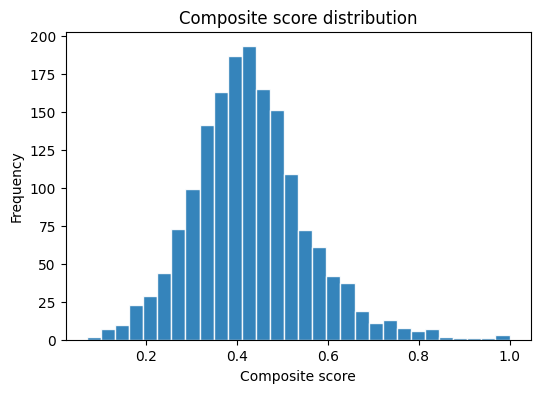

21:11:37  INFO     [   4.8s] Chart saved: score_distribution.png
21:11:37  INFO     [   4.8s] After pre-filter: 805 pairs
21:11:37  INFO     [   4.9s] Running greedy baseline …
21:11:37  INFO     [   5.0s] Running MILP …
21:11:38  INFO     [   5.5s] MILP done: status=optimal ObjVal=90.9469 SolveTime=0.39s
21:11:38  INFO     [   5.5s] Running score-only baseline …


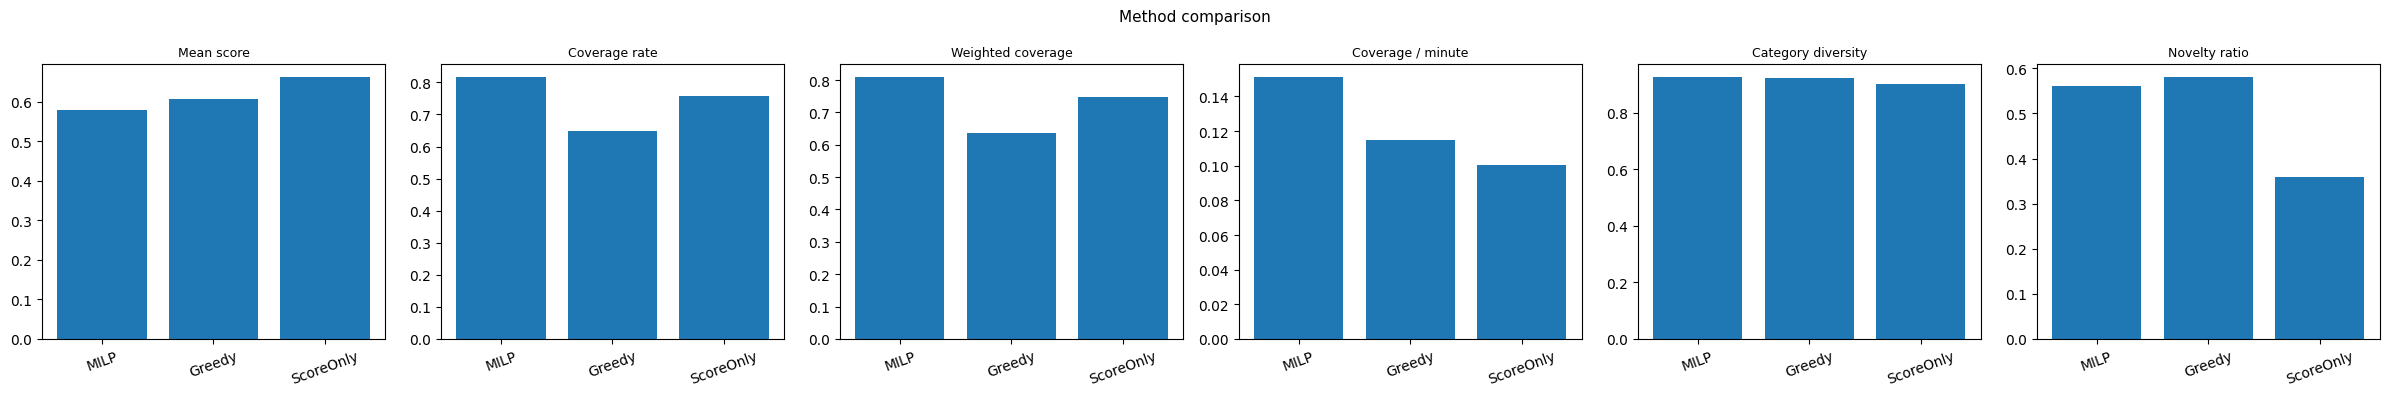

21:11:40  INFO     [   7.1s] Chart saved: method_comparison.png
21:11:40  INFO     [   7.1s] Running sensitivity over 72 configurations …
21:11:40  INFO     [   7.5s] MILP done: status=optimal ObjVal=87.1359 SolveTime=0.22s
21:11:40  INFO     [   7.8s] MILP done: status=optimal ObjVal=86.1600 SolveTime=0.22s
21:11:41  INFO     [   8.3s] MILP done: status=optimal ObjVal=86.0485 SolveTime=0.26s
21:11:41  INFO     [   8.8s] MILP done: status=optimal ObjVal=85.9848 SolveTime=0.31s
21:11:42  INFO     [   9.1s] MILP done: status=optimal ObjVal=85.8034 SolveTime=0.21s
21:11:42  INFO     [   9.4s] MILP done: status=optimal ObjVal=85.1277 SolveTime=0.22s
21:11:42  INFO     [   9.8s] MILP done: status=optimal ObjVal=90.2786 SolveTime=0.18s
21:11:43  INFO     [  10.1s] MILP done: status=optimal ObjVal=90.6667 SolveTime=0.19s
21:11:43  INFO     [  10.6s] MILP done: status=optimal ObjVal=89.9230 SolveTime=0.29s
21:11:43  INFO     [  10.9s] MILP done: status=optimal ObjVal=90.0818 SolveTime=0.19s
21


=== METHOD COMPARISON ===
   method  total_pairs_selected  mean_selected_score  mean_review_minutes_per_job  mean_selected_per_job  mean_coverage_rate  mean_weighted_coverage_rate  ndcg_at_k  simpson_diversity  redundancy_uniqueness  coverage_per_review_min  jobs_underfilled  eligible_pairs
     MILP                   141             0.578667                    23.699583               4.700000            0.815556                     0.808058   0.868536           0.925329               0.560284                 0.150956                 8             805
   Greedy                   119             0.607229                    23.248017               3.966667            0.650000                     0.636707   0.794923           0.921948               0.579832                 0.115058                20             805
ScoreOnly                   148             0.661832                    33.038733               4.933333            0.758889                     0.747858   0.994704           

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# 9) MAIN
# ══════════════════════════════════════════════════════════════════════════════

def serialise_sets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if out[col].apply(lambda v: isinstance(v, (set, frozenset))).any():
            out[col] = out[col].map(lambda v: sorted(list(v)) if isinstance(v, set) else v)
    return out


def main() -> None:
    log.info("=" * 60)
    log.info("Resume Shortlisting – business-grounded v4")
    log.info("=" * 60)

    # load
    resume_df = load_resume_data(RESUME_FILE)
    job_df = load_job_data(JOB_FILE)
    resume_df = balanced_sample_resumes(resume_df, MAX_RESUMES_PER_CATEGORY)
    job_df = balanced_sample_jobs(job_df, MAX_JOBS_PER_TITLE, MAX_TOTAL_JOBS)
    log.info("[%s] Sampled %d resumes, %d jobs", elapsed(), len(resume_df), len(job_df))

    # features
    resume_df, job_df = add_skill_sets(resume_df, job_df)
    resume_df = build_redundancy_clusters(resume_df, REDUNDANCY_SIM_THRESHOLD)
    job_df["required_skills"] = job_df.apply(lambda r: infer_job_required_skills(r["skill_set"], r["job_text_clean"], MUST_HAVE_TOP_K), axis=1)

    pair_df = build_pair_table(resume_df, job_df)
    plot_score_distribution(pair_df)
    pair_df_filtered = prefilter_top_candidates(pair_df, TOP_N_PER_JOB_PREFILTER)

    # exports of cleaned inputs
    serialise_sets(resume_df).to_csv(OUT_DIR / "resumes_cleaned.csv", index=False)
    serialise_sets(job_df).to_csv(OUT_DIR / "jobs_cleaned.csv", index=False)
    serialise_sets(pair_df_filtered).to_csv(OUT_DIR / "pair_scores.csv", index=False)

    # baselines + warm start
    log.info("[%s] Running greedy baseline …", elapsed())
    greedy_df = greedy_baseline(pair_df_filtered)
    log.info("[%s] Running MILP …", elapsed())
    opt_res = solve_resume_shortlisting(pair_df_filtered, job_df, warm_start_df=greedy_df)
    log.info("[%s] Running score-only baseline …", elapsed())
    score_df = score_only_baseline(pair_df_filtered)

    # evaluation
    opt_eval = evaluate_solution(opt_res.selected_pairs, pair_df_filtered, job_df, "MILP", SHORTLIST_SIZE_DEFAULT, REVIEW_BUDGET_MINUTES_DEFAULT)
    greedy_eval = evaluate_solution(greedy_df, pair_df_filtered, job_df, "Greedy", SHORTLIST_SIZE_DEFAULT, REVIEW_BUDGET_MINUTES_DEFAULT)
    score_eval = evaluate_solution(score_df, pair_df_filtered, job_df, "ScoreOnly", SHORTLIST_SIZE_DEFAULT, REVIEW_BUDGET_MINUTES_DEFAULT)
    comparison = pd.DataFrame([opt_eval, greedy_eval, score_eval])
    plot_method_comparison(comparison)

    # sensitivity
    sensitivity = run_sensitivity(pair_df_filtered, job_df)

    # exports
    serialise_sets(opt_res.selected_pairs).to_csv(OUT_DIR / "selected_pairs_milp.csv", index=False)
    opt_res.shortlist_summary.to_csv(OUT_DIR / "shortlist_summary_milp.csv", index=False)
    opt_res.coverage_summary.to_csv(OUT_DIR / "coverage_summary_milp.csv", index=False)
    serialise_sets(greedy_df).to_csv(OUT_DIR / "selected_pairs_greedy.csv", index=False)
    serialise_sets(score_df).to_csv(OUT_DIR / "selected_pairs_score_only.csv", index=False)
    comparison.to_csv(OUT_DIR / "method_comparison.csv", index=False)
    sensitivity.to_csv(OUT_DIR / "sensitivity_analysis.csv", index=False)

    print("\n=== METHOD COMPARISON ===")
    print(comparison.to_string(index=False))
    print("\n=== MILP SHORTLIST SUMMARY ===")
    print(opt_res.shortlist_summary.head(10).to_string(index=False))
    print("\nSaved outputs to:", OUT_DIR.resolve())


if __name__ == "__main__":
    main()
